In [ ]:
import sys
sys.path.append("src")

import numpy as np
from detection import bandpass_filter, combined_signal, detect_spikes
from waveforms import extract_waveforms

npx_path = "data/raw/c37_npx_raw.bin"
npx_channels = 384
npx_samples = 4050171
fs = 30000

npx_recording = np.memmap(npx_path, mode='r', dtype=np.int16, order='C')
npx_recording = npx_recording.reshape((npx_channels, npx_samples), order='F')

channels_subset = list(range(180, 220))
subset_data = npx_recording[channels_subset, :].T.astype(np.float32)
filtered = bandpass_filter(subset_data, fs)

combo = combined_signal(filtered, method="sum_sq")
detected_spike_times = detect_spikes(combo, fs)
print(f"Detected {len(detected_spike_times)} spikes")

In [2]:
def extract_waveforms(filtered, spike_times, fs, window_ms=2.0):
    window_samples = int((window_ms / 1000) * fs)
    waveforms = []
    valid_times = []
    for t in spike_times:
        if t - window_samples >= 0 and t + window_samples < len(filtered):
            snippet = filtered[t - window_samples : t + window_samples, :]  # (time, channels)
            waveforms.append(snippet)
            valid_times.append(t)
    return np.array(waveforms), np.array(valid_times)

waveforms, valid_spike_times = extract_waveforms(filtered, detected_spike_times, fs)
print(f"Extracted {len(waveforms)} waveforms, shape each: {waveforms.shape[1:]}")  # (time, channels)

Extracted 2685 waveforms, shape each: (120, 40)


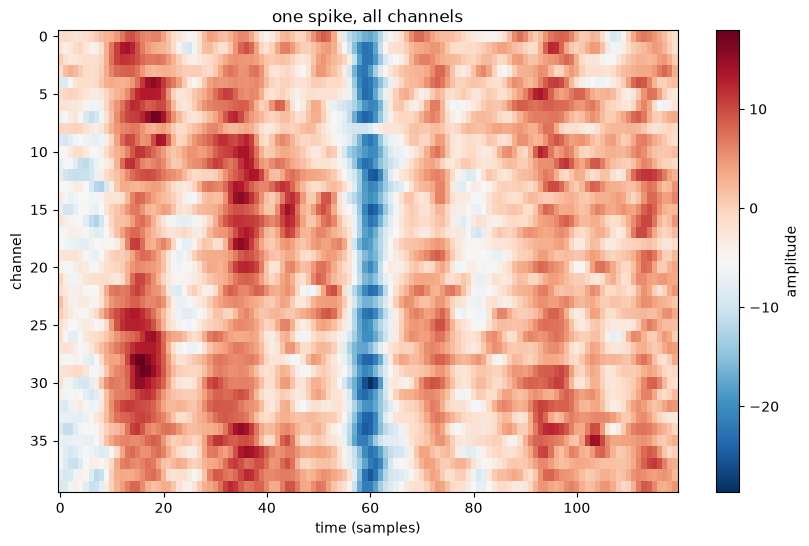

In [3]:
import matplotlib.pyplot as plt

example = waveforms[0]  # shape: (time, channels)

plt.figure(figsize=(10, 6))
plt.imshow(example.T, aspect='auto', cmap='RdBu_r')
plt.xlabel("time (samples)")
plt.ylabel("channel")
plt.title("one spike, all channels")
plt.colorbar(label="amplitude")
plt.savefig("figures/example_waveform.png")
plt.show()

In [5]:
np.save("data/raw/waveforms.npy", waveforms)
np.save("data/raw/valid_spike_times.npy", valid_spike_times)
print("saved waveforms")

saved waveforms
